In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-12 15:01:03,207	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Dataset Overview

We use a publicly available **rat hippocampus dataset** [Grosmark & Buzsáki, 2016](https://www.science.org/doi/abs/10.1126/science.aad1935), previously used in neuronal manifold learning (e.g., CEBRA, PI-VAE). It contains **spiking activity** recorded as the rat navigates a 1.6m linear track, along with behavioral variables:  
- **Position (continuous-valued)**  
- **Running direction (discrete-valued: left/right)**  

## Loading the Data

As a first step, load your time-series brain recordings (`x`) and behavioral (`b`) data. For this demo, we use spiking acitvity from the rat **Gatsby**.

If you are using your own data it should be formatted as follows:

    x: NumPy array, shape = (timepoints, features)

    b: NumPy array, shape = (timepoints,)

In [2]:
rat_names = ['achilles', 'gatsby','cicero', 'buddy']
rat_name = rat_names[1]
data = np.load(f'../datasets/raw/rat_hippocampus/{rat_name}.npz')
x, b = data['x'], data['b']

Let's take a look at the data.

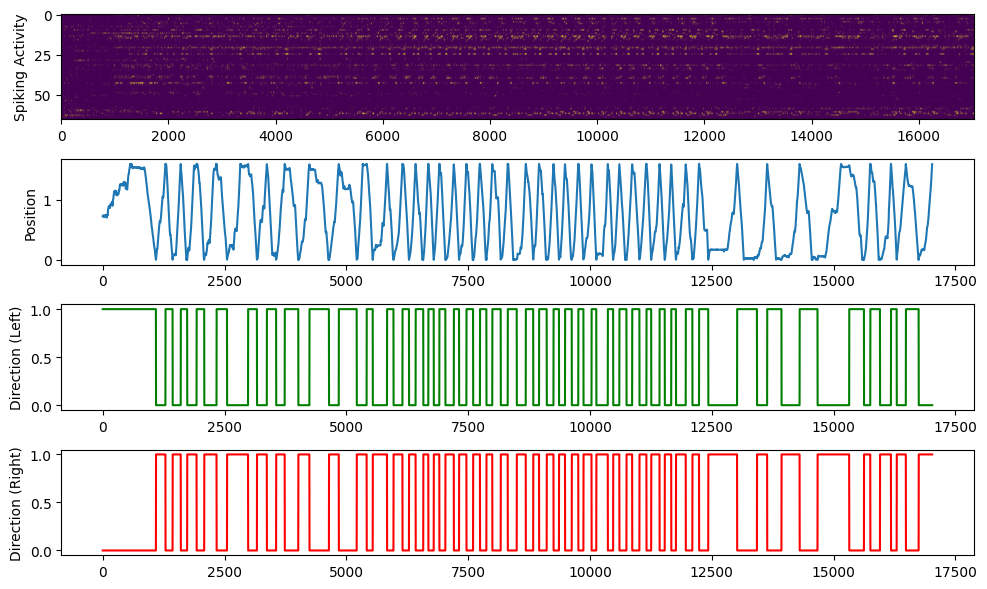

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 6))

axes[0].imshow(x.T, aspect='auto', vmin=0, vmax=0.1)
axes[0].set_ylabel('Spiking Activity')

axes[1].plot(b[:, 0])
axes[1].set_ylabel('Position')

axes[2].plot(b[:, 1], c='g')
axes[2].set_ylabel('Direction (Left)')

axes[3].plot(b[:, 2], c='r')
axes[3].set_ylabel('Direction (Right)')

plt.tight_layout()
plt.show()

## Preparing Data for BunDLe-Net  

The **`prep_data`** function transforms the pre-processed brain activity (`x`) and behavioral (`b`) data into a format suitable for the **BunDLe-Net** model. The **`win`** parameter specifies the window length, and allows us to perform a time delay embedding:
- **`win=1`**: Embeds a single time step.  
- **`win>1`**: Embeds a window of time-slices.

#### Output Shapes  
- **Neuronal data (`x_`)**: Shaped as **(t - win, 2, win, n)**, where:  
  - `x_[:,0,:,:]` represents $X_t$  
  - `x_[:,1,:,:]` represents $X_{t+1}$
  - the first dim denotes time-steps
  - the last dim denotes feature number
- **Behavioral data (`b_`)**: Shaped as **(t - win, ...)** to maintain synchronization with `x_`.  

We now apply `prep_data` with `win=20`:  

In [4]:
print(x.shape, b.shape)
x_, b_ = prep_data(x, b, win=20)
print(x_.shape, b_.shape)

(17026, 66) (17026, 3)
(17006, 2, 20, 66) (17006, 3)


## Training BunDLe-Net

Here, we train BunDLe-Net on the prepared neuronal and behavioral data. We use **PCA initialization**, which initializes the embeddings using the PCA of the data, providing a starting point for training.

In [5]:
algorithm = 'BunDLe-Net'
model = BunDLeNet(latent_dim=3, num_behaviour=b_.shape[1], input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='continuous',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=200,
    initialisation='pca_init'
)

/home/akshey/Desktop/PhD/Code_repositories/NC-MCM/ncmcm/bundlenet/bundlenet.py:200: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.tau.load_state_dict(torch.load(pca_mo

We plot the losses over the epochs in order to check whether the model has converged during training.

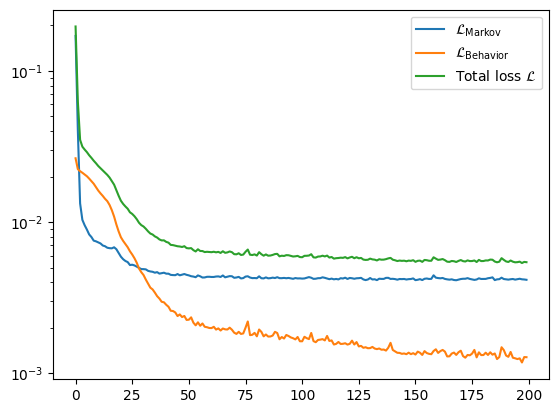

In [6]:
plt.figure()
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

Once we confirm the model has converged, we project the neuronal traces into the learned latent space.

In [7]:
y0_ = project_into_latent_space(x_[:,0], model)

## Visualising embedding
Next, we visualize the manifold in the latent space. We investigate how the manifold structure corresponds to the first behavioral variable (position). The plot below shows the 3D latent space with colors representing the position.

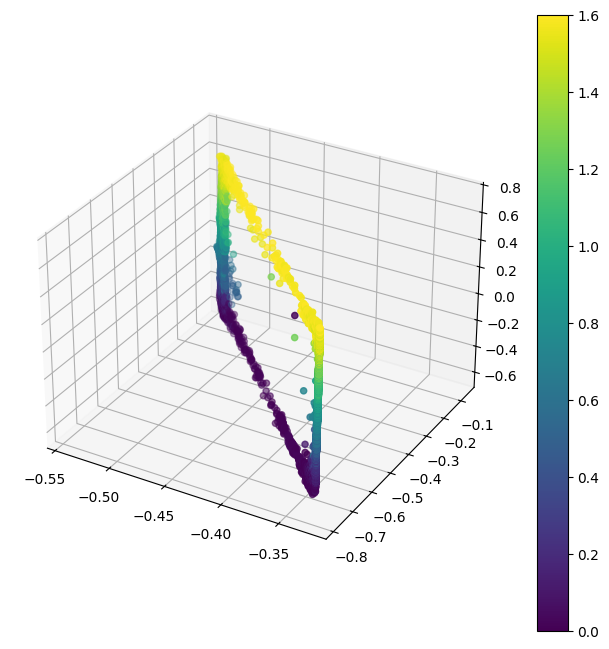

In [8]:
%matplotlib inline
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
true_y_line = ax.scatter(y0_[:, 0], y0_[:, 1], y0_[:, 2], c=b_[:,0])
plt.colorbar(true_y_line)
plt.show()

Using the LatentSpaceVisualiser class, we can explore the temporal dynamics in the phase space (state space). This class allows us to plot arrows between time points at $t$ and $t+1$, helping us identify temporal structures. In the plot, we see that the manifold is highly organized in bundled trajectories that form a loop, rather than criss-crossing trajectories. The color of the manifold is based on the second behavioral variable (direction).

/home/akshey/Desktop/PhD/Code_repositories/NC-MCM/ncmcm/visualisers/latent_space.py:186: RuntimeWarning: divide by zero encountered in divide
  kwargs.setdefault('arrow_length_ratio', 0.01 / np.linalg.norm(d))


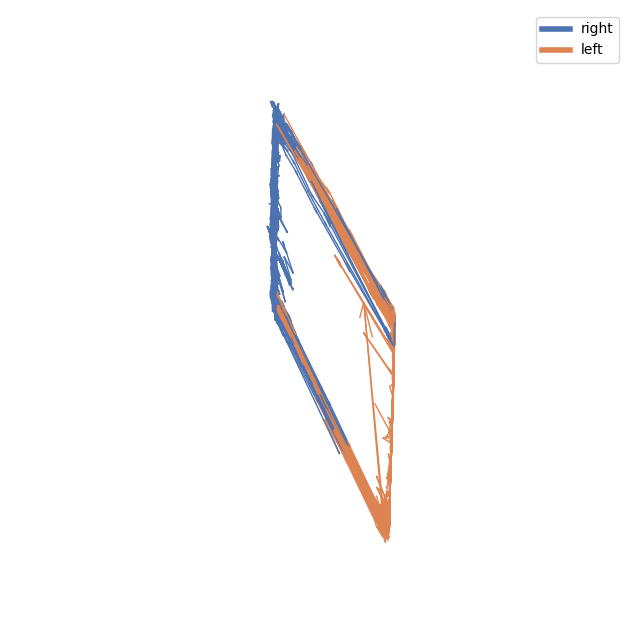

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [9]:
vis = LatentSpaceVisualiser(y0_, b_[:, 1].astype(int), b_names=['right', 'left'])
vis.plot_phase_space(filename=f'../figures/phase_space_dynamics_{algorithm}_rat_{rat_name}.png')